In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv('amazon_prime_titles.csv')

In [ ]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [ ]:
data.drop(['show_id'],axis=1,inplace=True)
data.drop(['description'],axis=1,inplace=True)

In [ ]:
data.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama"
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International"
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense"
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary
4,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy"


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          9668 non-null   object
 1   title         9668 non-null   object
 2   director      7585 non-null   object
 3   cast          8435 non-null   object
 4   country       672 non-null    object
 5   date_added    155 non-null    object
 6   release_year  9668 non-null   int64 
 7   rating        9331 non-null   object
 8   duration      9668 non-null   object
 9   listed_in     9668 non-null   object
dtypes: int64(1), object(9)
memory usage: 755.4+ KB


In [ ]:
data.isna().sum()

,0
type,0
title,0
director,2083
cast,1233
country,8996
date_added,9513
release_year,0
rating,337
duration,0
listed_in,0


In [ ]:
data['director'].fillna('Unavailable',inplace=True)
data['cast'].fillna('Unavailable',inplace=True)
data['country'].fillna('Unavailable',inplace=True)
data['date_added']=data['date_added'].ffill()
data['rating']=data['rating'].fillna(data['rating'].mode()[0])

/tmp/ipykernel_5932/2963635335.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['director'].fillna('Unavailable',inplace=True)
/tmp/ipykernel_5932/2963635335.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [ ]:
data.isna().sum()

,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [ ]:
data['date_added']=pd.to_datetime(data['date_added'],errors="coerce")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          9668 non-null   object        
 1   title         9668 non-null   object        
 2   director      9668 non-null   object        
 3   cast          9668 non-null   object        
 4   country       9668 non-null   object        
 5   date_added    9668 non-null   datetime64[ns]
 6   release_year  9668 non-null   int64         
 7   rating        9668 non-null   object        
 8   duration      9668 non-null   object        
 9   listed_in     9668 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 755.4+ KB


In [ ]:
filtered_directors=data[data['director']!='Unavailable']
top_directors=filtered_directors['director'].value_counts()[:10]

In [ ]:
top_directors

,count
director,
Mark Knight,113
Cannis Holder,61
Moonbug Entertainment,37
Jay Chapman,34
Arthur van Merwijk,30
Manny Rodriguez,22
John English,20
1,16
Brian Volk-Weiss,15


/tmp/ipykernel_5932/1161730014.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values,y=top_directors.index,palette='plasma')


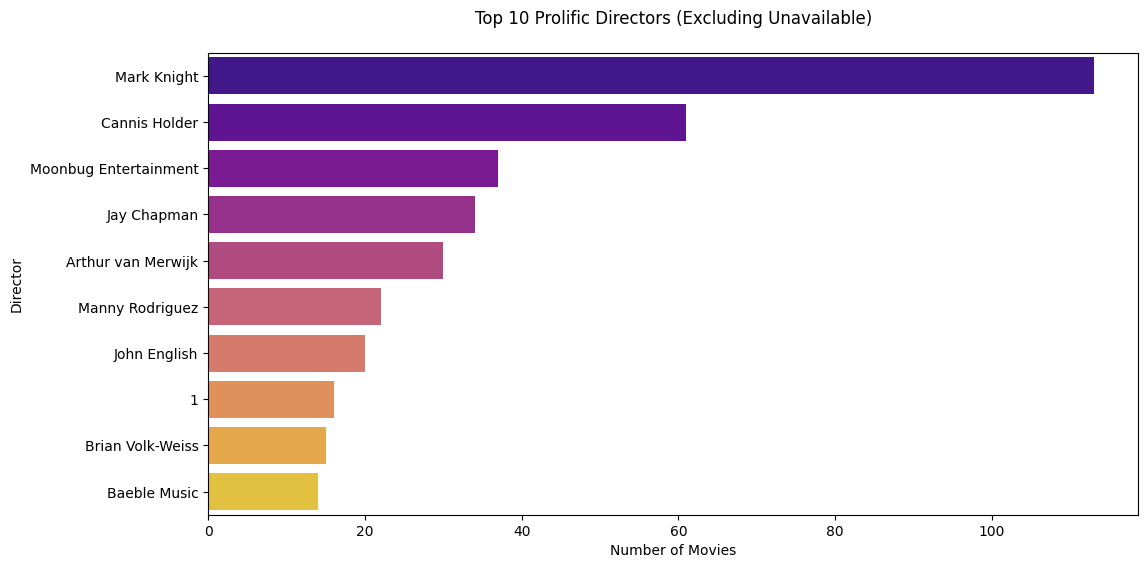

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_directors.values,y=top_directors.index,palette='plasma')
plt.title('Top 10 Prolific Directors (Excluding Unavailable)\n')
plt.xlabel('Number of Movies')
plt.ylabel('Director')
plt.show()

In [ ]:
filtered_actors=data[data['cast']!='Unavailable']
top_actors=filtered_actors['cast'].value_counts()[:10]

/tmp/ipykernel_5932/3765729575.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actors.values,y=top_actors.index,palette='plasma')


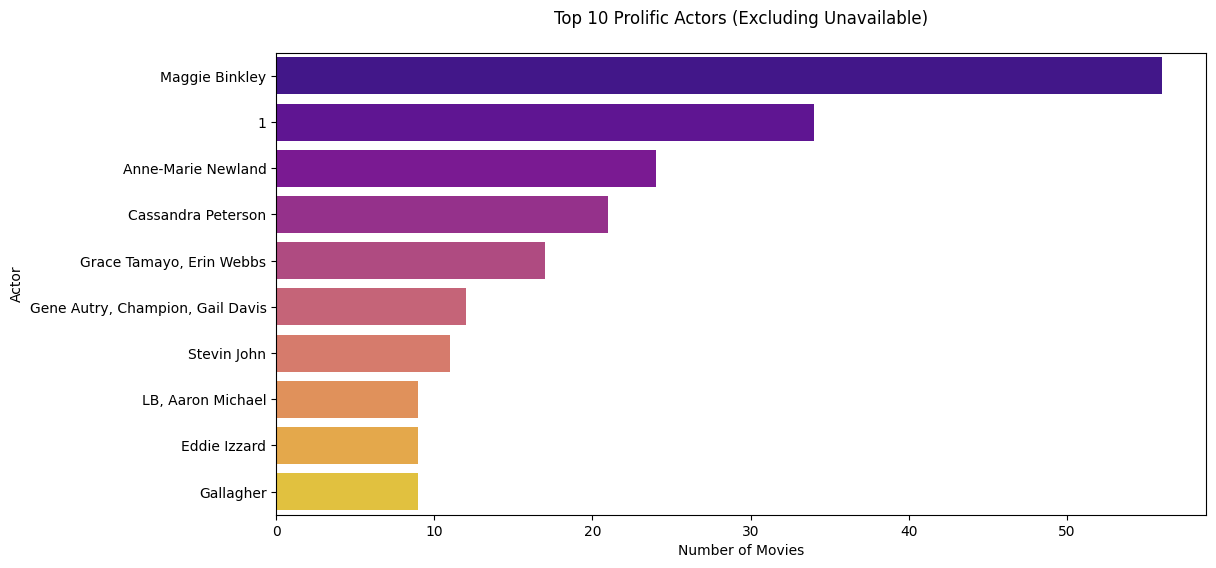

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_actors.values,y=top_actors.index,palette='plasma')
plt.title('Top 10 Prolific Actors (Excluding Unavailable)\n')
plt.xlabel('Number of Movies')
plt.ylabel('Actor')
plt.show()

/tmp/ipykernel_5932/44964522.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data,x='type',palette='viridis')


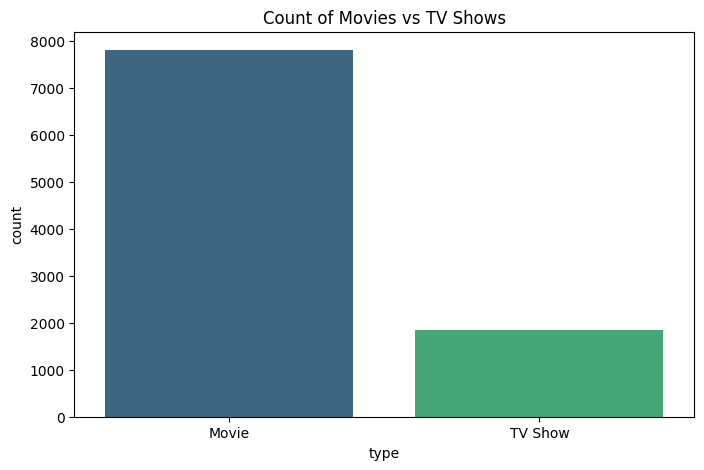

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=data,x='type',palette='viridis')
plt.title('Count of Movies vs TV Shows')
plt.show()

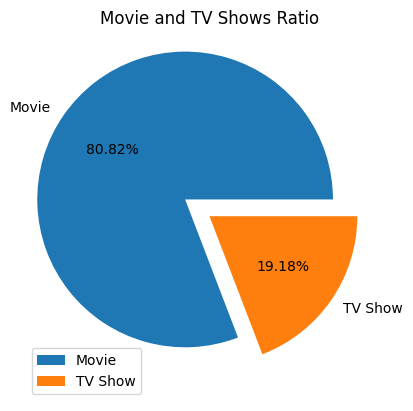

In [ ]:
plt.pie(data['type'].value_counts(),labels=data['type'].value_counts().index,autopct='%1.2f%%',explode=[0.2,0])
plt.title('Movie and TV Shows Ratio')
plt.legend()
plt.show()

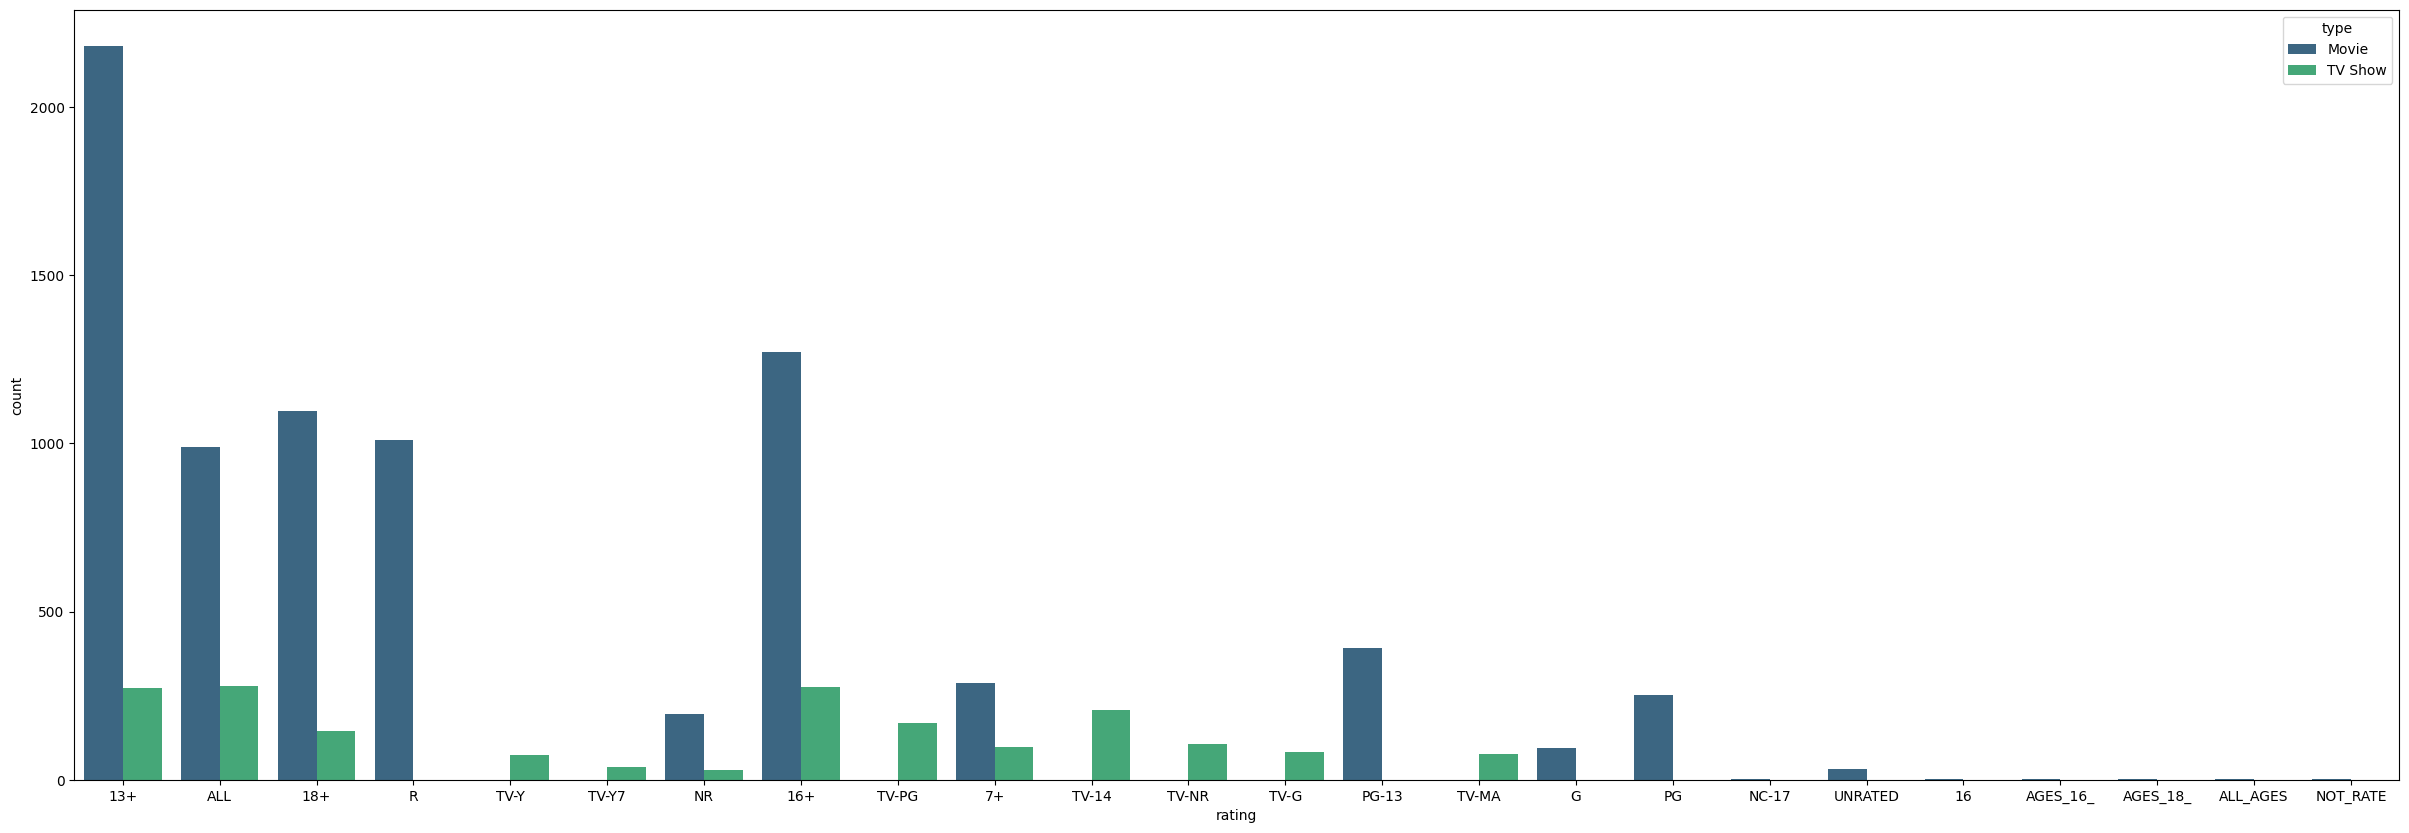

In [ ]:
plt.figure(figsize=(30,10))
sns.countplot(x='rating',data=data,hue='type',palette='viridis')
plt.show()

In [ ]:
filtered_country=data[data['country']!='Unavailable']
country_counts=filtered_country['country'].value_counts()


In [ ]:
top_countries=country_counts.nlargest(3).index
top_countries

Index(['United States', 'India', 'United Kingdom'], dtype='object', name='country')

In [ ]:
df_top_countries=filtered_country[filtered_country['country'].isin(top_countries)]
df_top_countries

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International"
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,13+,74 min,"Action, Drama, Suspense"
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,2021-03-30,2014,13+,69 min,Documentary
4,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,2021-03-30,1989,13+,45 min,"Drama, Fantasy"
5,Movie,Living With Dinosaurs,Paul Weiland,"Gregory Chisholm, Juliet Stevenson, Brian Hens...",United Kingdom,2021-03-30,1989,13+,52 min,"Fantasy, Kids"
...,...,...,...,...,...,...,...,...,...,...
9604,Movie,Bride Wars,Gary Winick,"Kate Hudson, Anne Hathaway, Kristen Johnston, ...",United States,2021-10-08,2009,PG,89 min,Comedy
9614,Movie,What Happens in Vegas,Tom Vaughan,"Cameron Diaz, Ashton Kutcher, Rob Corddry, ...",United States,2021-10-08,2008,PG-13,99 min,Comedy
9641,Movie,Marley & Me,David Frankel,"Owen Wilson, Jennifer Aniston",United States,2021-10-10,2008,PG,116 min,"Comedy, Drama, Kids"
9643,Movie,Love & Other Drugs,Edward Zwick,"K K, Jake Gyllenhaal, Anne Hathaway, Oliver Pl...",United States,2021-10-10,2010,R,112 min,"Comedy, Drama"


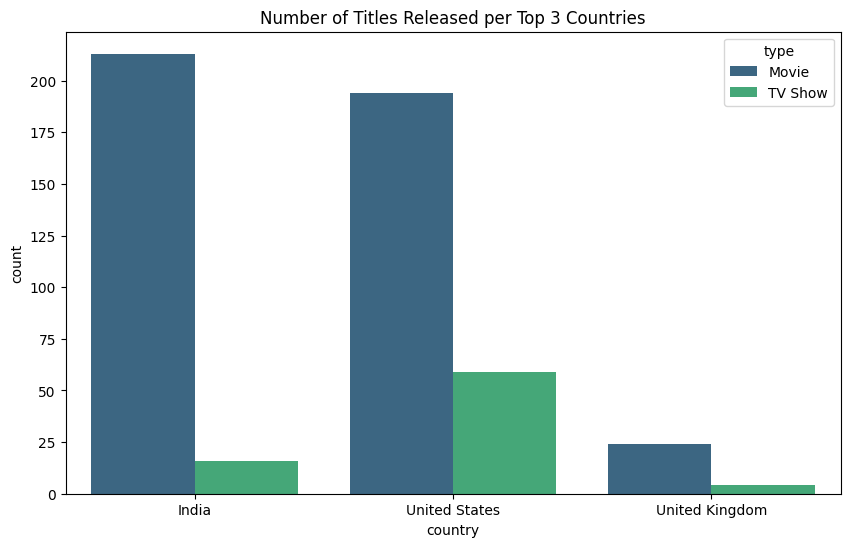

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_top_countries,x='country',hue='type',palette='viridis')
plt.title('Number of Titles Released per Top 3 Countries')
plt.show()

In [ ]:
year_counts=data['release_year'].value_counts()

In [ ]:
top_years=year_counts.nlargest(10).index

In [ ]:
df_top_years=data[data['release_year'].isin(top_years)]

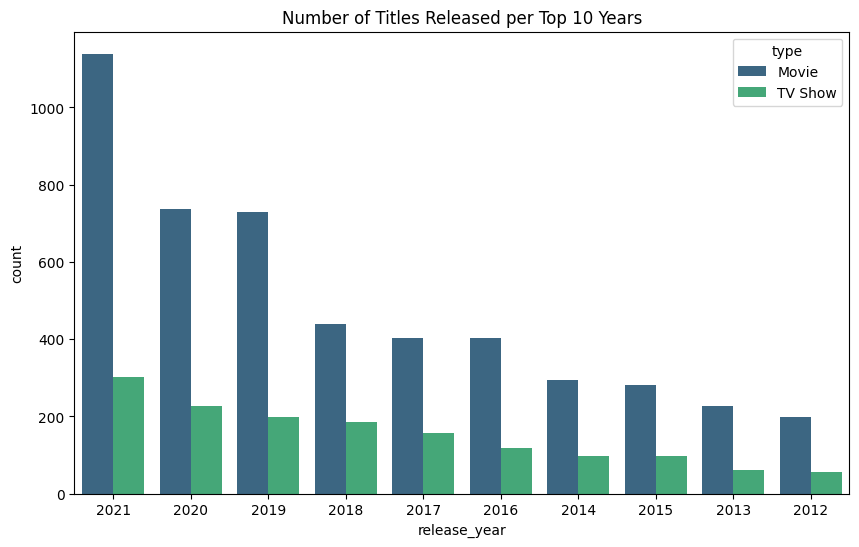

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_top_years,x='release_year',hue='type',palette='viridis',order=top_years)
plt.title('Number of Titles Released per Top 10 Years')
plt.show()

/tmp/ipykernel_5932/3563050570.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=genres_exploded,y='Genres',palette='viridis')


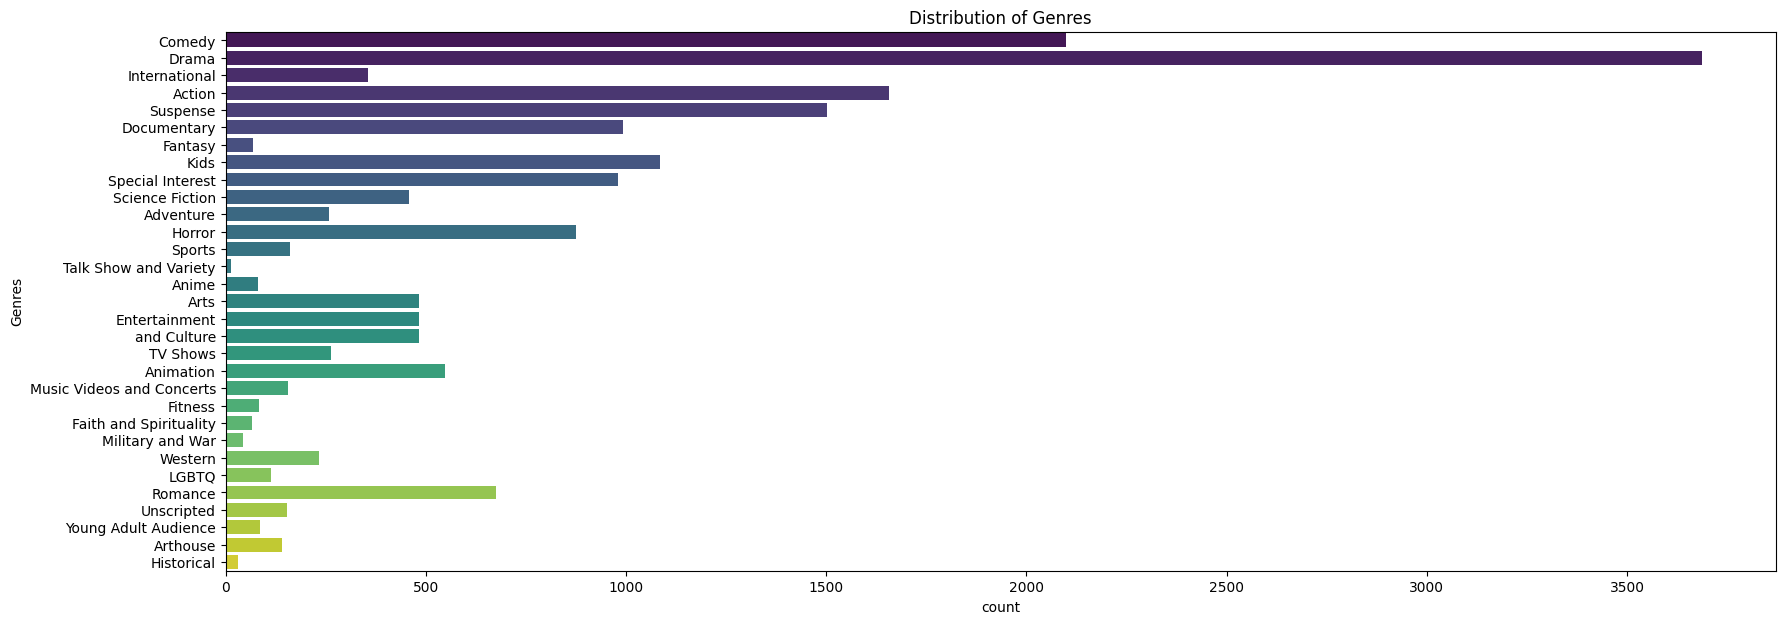

In [ ]:
#Distribution of genres
#spliting of genres

data['Genres']=data['listed_in'].apply(lambda x:x.split(', '))
#exploding the genres into separate rows
genres_exploded=data.explode('Genres')
x=genres_exploded['Genres'].value_counts()[:20].index
plt.figure(figsize=(20,7))
sns.countplot(data=genres_exploded,y='Genres',palette='viridis')
plt.title('Distribution of Genres')
plt.show()

In [ ]:
data['duration'].unique()

array(['113 min', '110 min', '74 min', '69 min', '45 min', '52 min',
       '98 min', '131 min', '87 min', '92 min', '88 min', '93 min',
       '94 min', '46 min', '96 min', '1 Season', '104 min', '62 min',
       '50 min', '3 Seasons', '2 Seasons', '86 min', '36 min', '37 min',
       '103 min', '9 min', '18 min', '14 min', '20 min', '19 min',
       '22 min', '60 min', '6 min', '54 min', '5 min', '84 min',
       '126 min', '125 min', '109 min', '89 min', '85 min', '56 min',
       '40 min', '111 min', '33 min', '34 min', '95 min', '99 min',
       '78 min', '4 Seasons', '77 min', '55 min', '53 min', '115 min',
       '58 min', '49 min', '135 min', '91 min', '64 min', '59 min',
       '48 min', '122 min', '90 min', '102 min', '65 min', '114 min',
       '136 min', '70 min', '138 min', '100 min', '480 min', '4 min',
       '30 min', '152 min', '68 min', '57 min', '7 Seasons', '31 min',
       '151 min', '149 min', '9 Seasons', '141 min', '121 min', '79 min',
       '140 min', '51 min'

In [ ]:
data['duration']=data['duration'].apply(lambda x:int(x.split()[0]))

/tmp/ipykernel_5932/2948335708.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_movies.sort_values(by='duration',ascending=False).head(10),y='title',x='duration',palette='viridis')
/tmp/ipykernel_5932/2948335708.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tv_shows.sort_values(by='duration',ascending=False).head(10),y='title',x='duration',palette='viridis')


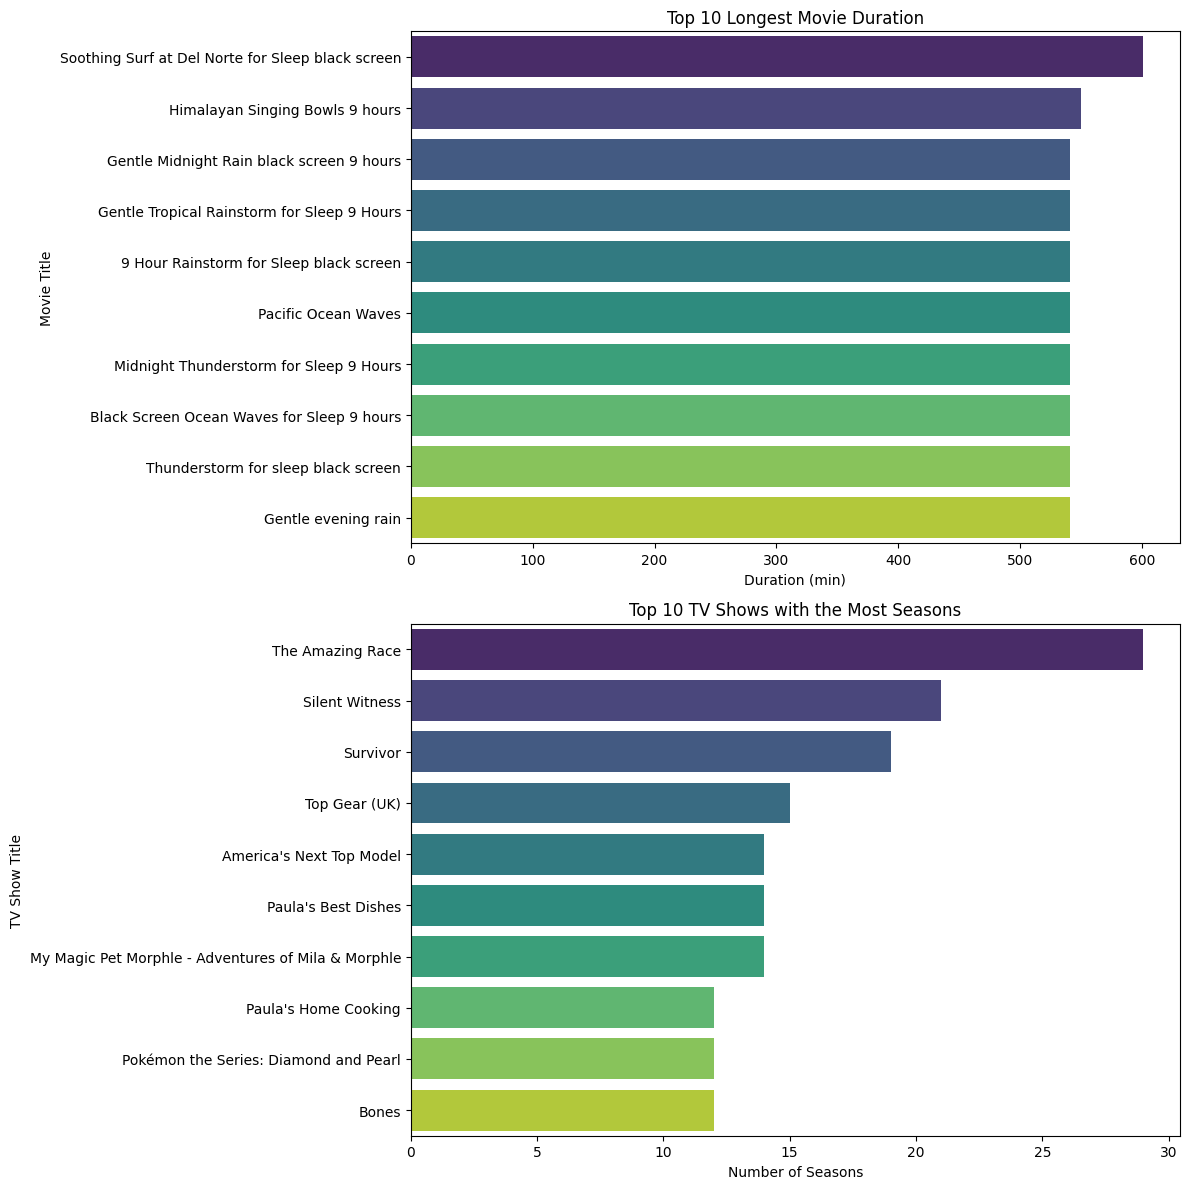

In [ ]:
df_movies=data[data['type']=='Movie'].copy()
df_tv_shows=data[data['type']=='TV Show'].copy()

plt.figure(figsize=(12,12))
#subplot1: top 10 longest movie duration
plt.subplot(2,1,1)
sns.barplot(data=df_movies.sort_values(by='duration',ascending=False).head(10),y='title',x='duration',palette='viridis')
plt.title('Top 10 Longest Movie Duration')
plt.xlabel('Duration (min)')
plt.ylabel('Movie Title')

#subplot 2: top 10 tv shows with the most seasons
plt.subplot(2,1,2)
sns.barplot(data=df_tv_shows.sort_values(by='duration',ascending=False).head(10),y='title',x='duration',palette='viridis')
plt.title('Top 10 TV Shows with the Most Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('TV Show Title')
plt.tight_layout()
plt.show()